# Advanced EDA: Medical Symptom Text and Audio Dataset for Medical Diagnosis Research

This notebook provides an advanced exploratory data analysis (EDA) for the research: **NLP and Deep Learning for Text and Audio Classification in Medical Diagnosis**. The primary focus is on analyzing the `phrase` (symptom description) and `prompt` (medical condition) fields to evaluate their potential for classification tasks.

## Research Questions

**RQ1:** What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?

**RQ2:** How effective is NLP in the classifying of patient symptoms from audio data?

## Research Hypotheses

**H10 (Null):** Text analysis of patient symptoms results in insufficient precision and recall for provider decision support.

**H1a (Alternative):** Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

**H20 (Null):** Audio analysis of patient symptoms yields both precision and recall metrics that are insufficient for effective provider decision support.

**H2a (Alternative):** Audio analysis of patient symptoms results in precision and recall sufficient for provider decision support.

## 1. Library Imports and Setup
Import all required libraries for data manipulation, visualization, text, and audio analysis. Each import is commented for clarity.

In [1]:
# Data manipulation and analysis
import pandas as pd  # For handling tabular data
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns  # For advanced visualizations
import os  # For file and directory operations
import glob  # For file pattern matching
import re  # For regular expressions
from collections import Counter  # For counting word frequencies
import warnings  # For suppressing warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Text processing
import nltk  # Natural Language Toolkit for text analysis
from nltk.corpus import stopwords  # For removing common English words
from nltk.tokenize import word_tokenize  # For splitting text into words
from nltk.stem import WordNetLemmatizer  # For reducing words to their base form
from wordcloud import WordCloud  # For generating word clouds

# Advanced text analysis
from nltk.util import ngrams  # For creating n-grams
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer  # For text vectorization
from sklearn.decomposition import PCA, TruncatedSVD  # For dimensionality reduction
from sklearn.metrics.pairwise import cosine_similarity  # For measuring text similarity
from sklearn.cluster import KMeans  # For text clustering

# Audio processing
import librosa  # For audio feature extraction
import librosa.display  # For visualizing audio features
import soundfile as sf  # For reading audio files
import IPython.display as ipd  # For audio playback in notebook

# Visualization settings
plt.style.use('ggplot')  # Set plot style
plt.rcParams['figure.figsize'] = (12, 8)  # Set default figure size
sns.set(style='whitegrid')  # Set seaborn style
np.random.seed(42)  # Set random seed for reproducibility

# Download NLTK resources if not already present
try:
    nltk.data.find('tokenizers/punkt')  # Check for punkt tokenizer
    nltk.data.find('corpora/stopwords')  # Check for stopwords
    nltk.data.find('corpora/wordnet')  # Check for wordnet
except LookupError:
    nltk.download('punkt')  # Download punkt if missing
    nltk.download('stopwords')  # Download stopwords if missing
    nltk.download('wordnet')  # Download wordnet if missing

print("All libraries imported and environment set up.")  # Confirm setup

All libraries imported and environment set up.


[nltk_data] Downloading package punkt to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Data Loading and Initial Inspection
Load the metadata CSV and inspect the structure, focusing on the `phrase` and `prompt` fields. Clean and prepare the data for analysis.

In [2]:
# Define data paths for CSV and audio directories
BASE_PATH = r"G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent"  # Base path
CSV_PATH = os.path.join(BASE_PATH, "overview-of-recordings.csv")  # Path to metadata CSV
RECORDINGS_PATH = os.path.join(BASE_PATH, "recordings")  # Path to audio recordings

# Load the metadata CSV into a DataFrame
# The CSV contains information about each audio recording and its associated text
metadata = pd.read_csv(CSV_PATH)  # Read CSV

# Standardize column names for consistency
metadata.columns = metadata.columns.str.lower().str.strip()  # Lowercase and strip

# Display the first few rows to understand the structure
print("Sample of the metadata:")  # Print header
display(metadata.head())  # Show first rows

# Focus on 'phrase' (symptom description) and 'prompt' (medical condition)
print("\nColumns in the dataset:", metadata.columns.tolist())  # Print columns

Sample of the metadata:


,audio_clipping,audio_clipping:confidence,background_noise_audible,background_noise_audible:confidence,overall_quality_of_the_audio,quiet_speaker,quiet_speaker:confidence,speaker_id,file_download,file_name,phrase,prompt,writer_id
0,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,43453425,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43453425_58166571.wav,When I remember her I feel down,Emotional pain,21665495
1,light_clipping,0.6803,no_noise,0.6803,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_43347848.wav,When I carry heavy things I feel like breaking...,Hair falling out,44088126
2,no_clipping,1.0000,no_noise,0.6655,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_53187202.wav,there is too much pain when i move my arm,Heart hurts,44292353
3,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,31349958,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_31349958_55816195.wav,My son had his lip pierced and it is swollen a...,Infected wound,43755034
4,no_clipping,1.0000,no_noise,1.0000,4.67,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_82524191.wav,My muscles in my lower back are aching,Infected wound,21665495



Columns in the dataset: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']


In [3]:
# Remove rows with missing 'phrase' or 'prompt' values, as these are essential for analysis
metadata = metadata.dropna(subset=['phrase', 'prompt'])  # Drop missing

# Check for missing values in all columns
missing = metadata.isnull().sum()  # Count missing
print("Missing values per column:")  # Print header
print(missing[missing > 0])  # Print only columns with missing

# Show basic statistics for phrase length and prompt distribution
metadata['phrase_length'] = metadata['phrase'].str.len()  # Number of characters in each phrase
metadata['word_count'] = metadata['phrase'].str.split().str.len()  # Number of words in each phrase

print("\nPhrase length (characters): min=", metadata['phrase_length'].min(), ", max=", metadata['phrase_length'].max(), ", mean=", metadata['phrase_length'].mean())  # Print stats
print("Word count: min=", metadata['word_count'].min(), ", max=", metadata['word_count'].max(), ", mean=", metadata['word_count'].mean())  # Print stats

print("\nNumber of unique prompts (medical conditions):", metadata['prompt'].nunique())  # Unique prompts
print("Top 10 most frequent prompts:")  # Header
print(metadata['prompt'].value_counts().head(10))  # Top 10

# Calculate dataset completeness percentage
total_records = len(metadata)  # Number of records
print(f"\nTotal records after cleaning: {total_records}")  # Print count
print(f"Dataset completeness: {total_records/len(pd.read_csv(CSV_PATH))*100:.2f}%")  # Print completeness

Missing values per column:
Series([], dtype: int64)

Phrase length (characters): min= 9 , max= 155 , mean= 50.02612220387329
Word count: min= 2 , max= 30 , mean= 10.543461942651254

Number of unique prompts (medical conditions): 25
Top 10 most frequent prompts:
prompt
Acne              328
Shoulder pain     320
Joint pain        318
Infected wound    306
Knee pain         305
Cough             293
Feeling dizzy     283
Muscle pain       282
Heart hurts       273
Ear ache          270
Name: count, dtype: int64

Total records after cleaning: 6661
Dataset completeness: 100.00%
Dataset completeness: 100.00%


## 3. Text Data Analysis: Phrase and Prompt
Explore the distribution, vocabulary, and patterns in the `phrase` and `prompt` fields. Visualize and statistically analyze the text data.

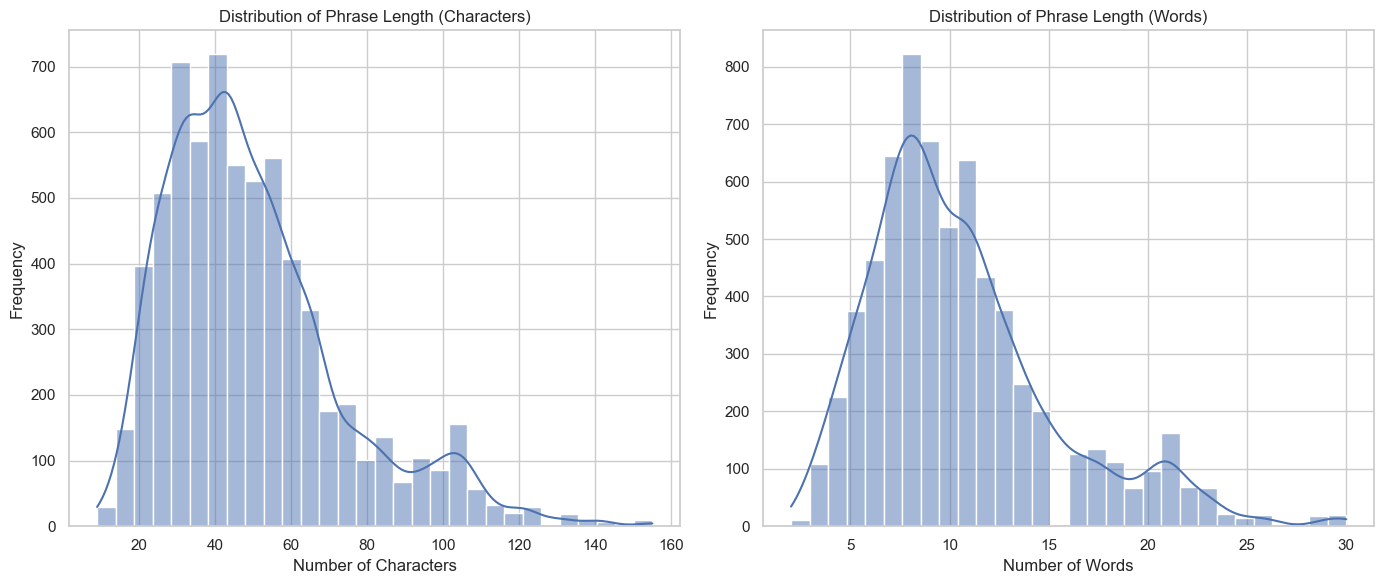

Descriptive Statistics for Phrase Length:
count    6661.000000
mean       50.026122
std        23.672184
min         9.000000
25%        33.000000
50%        45.000000
75%        61.000000
max       155.000000
Name: phrase_length, dtype: float64

Descriptive Statistics for Word Count:
count    6661.000000
mean       10.543462
std         4.807787
min         2.000000
25%         7.000000
50%        10.000000
75%        13.000000
max        30.000000
Name: word_count, dtype: float64

Number of outlier phrases (word count > 21): 228


In [4]:
# Plot the distribution of phrase lengths (characters and words)
plt.figure(figsize=(14, 6))  # Set figure size
plt.subplot(1, 2, 1)  # First subplot
sns.histplot(metadata['phrase_length'], bins=30, kde=True)  # Plot histogram of phrase length
plt.title('Distribution of Phrase Length (Characters)')  # Set title
plt.xlabel('Number of Characters')  # X label
plt.ylabel('Frequency')  # Y label

plt.subplot(1, 2, 2)  # Second subplot
sns.histplot(metadata['word_count'], bins=30, kde=True)  # Plot histogram of word count
plt.title('Distribution of Phrase Length (Words)')  # Set title
plt.xlabel('Number of Words')  # X label
plt.ylabel('Frequency')  # Y label
plt.tight_layout()  # Adjust layout
plt.show()  # Show plots

# Add descriptive statistics for phrase length and word count
print("Descriptive Statistics for Phrase Length:")  # Header
print(metadata['phrase_length'].describe())  # Print stats
print("\nDescriptive Statistics for Word Count:")  # Header
print(metadata['word_count'].describe())  # Print stats

# Identify outliers (phrases with extremely high word counts)
word_count_threshold = metadata['word_count'].quantile(0.95)  # 95th percentile
outliers = metadata[metadata['word_count'] > word_count_threshold]  # Outliers
print(f"\nNumber of outlier phrases (word count > {word_count_threshold:.0f}): {len(outliers)}")  # Print count

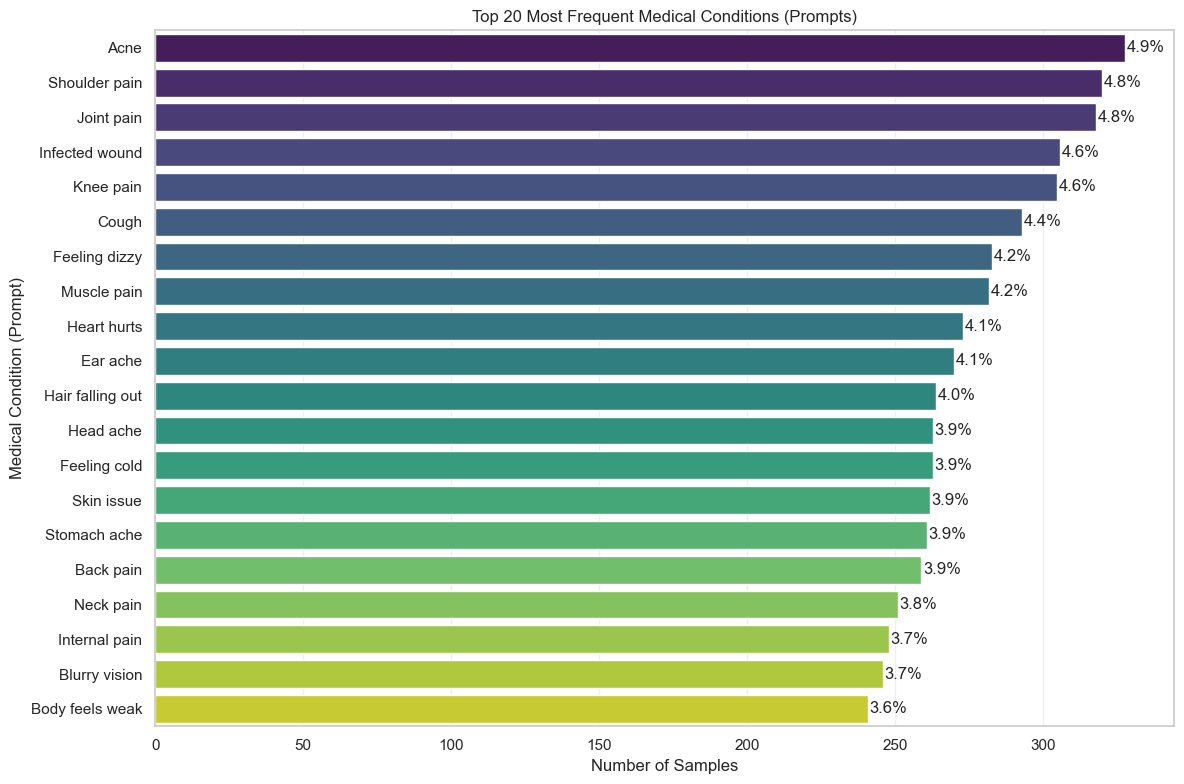

Top 20 prompts cover 80% of the dataset
The dataset has long-tail distribution: 5 prompts share only 20% of samples


In [5]:
# Plot the top 20 most common prompts (medical conditions)
top_n = 20  # Number of top prompts to show
plt.figure(figsize=(12, 8))  # Set figure size
prompt_counts = metadata['prompt'].value_counts().head(top_n)  # Get top prompts
sns.barplot(y=prompt_counts.index, x=prompt_counts.values, palette='viridis')  # Bar plot
plt.title(f'Top {top_n} Most Frequent Medical Conditions (Prompts)')  # Set title
plt.xlabel('Number of Samples')  # X label
plt.ylabel('Medical Condition (Prompt)')  # Y label
plt.grid(axis='x', alpha=0.3)  # Add grid

# Add percentage annotations to the bars
for i, count in enumerate(prompt_counts.values):
    percentage = 100 * count / len(metadata)  # Calculate percentage
    plt.text(count + 0.5, i, f"{percentage:.1f}%", va='center')  # Annotate

plt.tight_layout()  # Adjust layout
plt.show()  # Show plot

# Calculate cumulative distribution of prompts
cum_dist = np.cumsum(metadata['prompt'].value_counts().values) / len(metadata) * 100  # Cumulative %
top_coverage = np.argmax(cum_dist >= 80) + 1  # Prompts to cover 80%
print(f"Top {top_coverage} prompts cover 80% of the dataset")  # Print coverage
print(f"The dataset has long-tail distribution: {metadata['prompt'].nunique() - top_coverage} prompts share only 20% of samples")  # Print long tail

In [6]:
# Calculate vocabulary statistics for the entire dataset
all_phrases = ' '.join(metadata['phrase'].dropna())  # Concatenate all phrases
words = all_phrases.split()  # Split into words
unique_words = set(words)  # Unique words
vocab_size = len(unique_words)  # Vocabulary size
vocab_density = vocab_size / len(words) if len(words) > 0 else 0  # Density

print(f"Total words: {len(words)}")  # Print total words
print(f"Unique words: {vocab_size}")  # Print unique words
print(f"Vocabulary density (unique/total): {vocab_density:.4f}")  # Print density

# Calculate vocabulary richness by prompt (top 10 prompts)
top_prompts = metadata['prompt'].value_counts().head(10).index  # Top prompts
print("\nVocabulary richness by prompt (top 10):")  # Header
for prompt in top_prompts:
    prompt_phrases = ' '.join(metadata[metadata['prompt'] == prompt]['phrase'])  # All phrases for prompt
    prompt_words = prompt_phrases.split()  # Words for prompt
    prompt_unique = len(set(prompt_words))  # Unique words
    prompt_density = prompt_unique / len(prompt_words) if prompt_words else 0  # Density
    print(f"{prompt}: {prompt_unique} unique words, density: {prompt_density:.4f}")  # Print stats

Total words: 70230
Unique words: 1419
Vocabulary density (unique/total): 0.0202

Vocabulary richness by prompt (top 10):
Acne: 158 unique words, density: 0.0485
Shoulder pain: 133 unique words, density: 0.0412
Joint pain: 126 unique words, density: 0.0394
Infected wound: 212 unique words, density: 0.0472
Knee pain: 159 unique words, density: 0.0469
Cough: 124 unique words, density: 0.0529
Feeling dizzy: 97 unique words, density: 0.0356
Muscle pain: 132 unique words, density: 0.0423
Heart hurts: 132 unique words, density: 0.0464
Ear ache: 139 unique words, density: 0.0489


In [7]:
# Preprocess text: lowercase, remove punctuation, remove stopwords, lemmatize
lemmatizer = WordNetLemmatizer()  # Create lemmatizer
stop_words = set(stopwords.words('english'))  # Get stopwords

def preprocess(text):
    """
    Comprehensive text preprocessing function that:
    1. Converts text to lowercase
    2. Removes punctuation and special characters
    3. Removes stopwords
    4. Lemmatizes words to their base form
    """
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Apply preprocessing to all phrases
metadata['processed_phrase'] = metadata['phrase'].apply(preprocess)  # Preprocess
print(f"Preprocessing applied to {len(metadata)} phrases")  # Print count

# Example comparison
sample_idx = np.random.randint(0, len(metadata))  # Random index
print("\nPreprocessing example:")  # Header
print(f"Original: '{metadata.iloc[sample_idx]['phrase']}'")  # Print original
print(f"Processed: '{metadata.iloc[sample_idx]['processed_phrase']}'")  # Print processed

Preprocessing applied to 6661 phrases

Preprocessing example:
Original: 'My shoulder has agreat pain'
Processed: 'shoulder agreat pain'


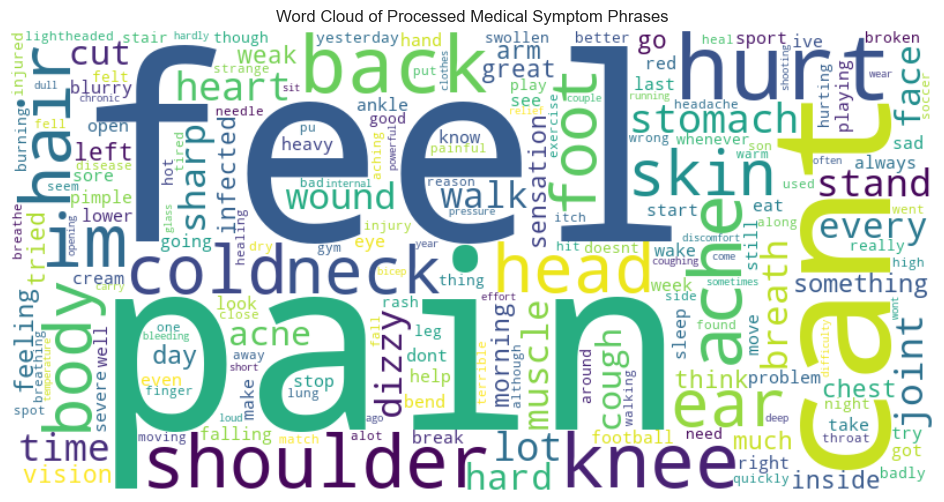

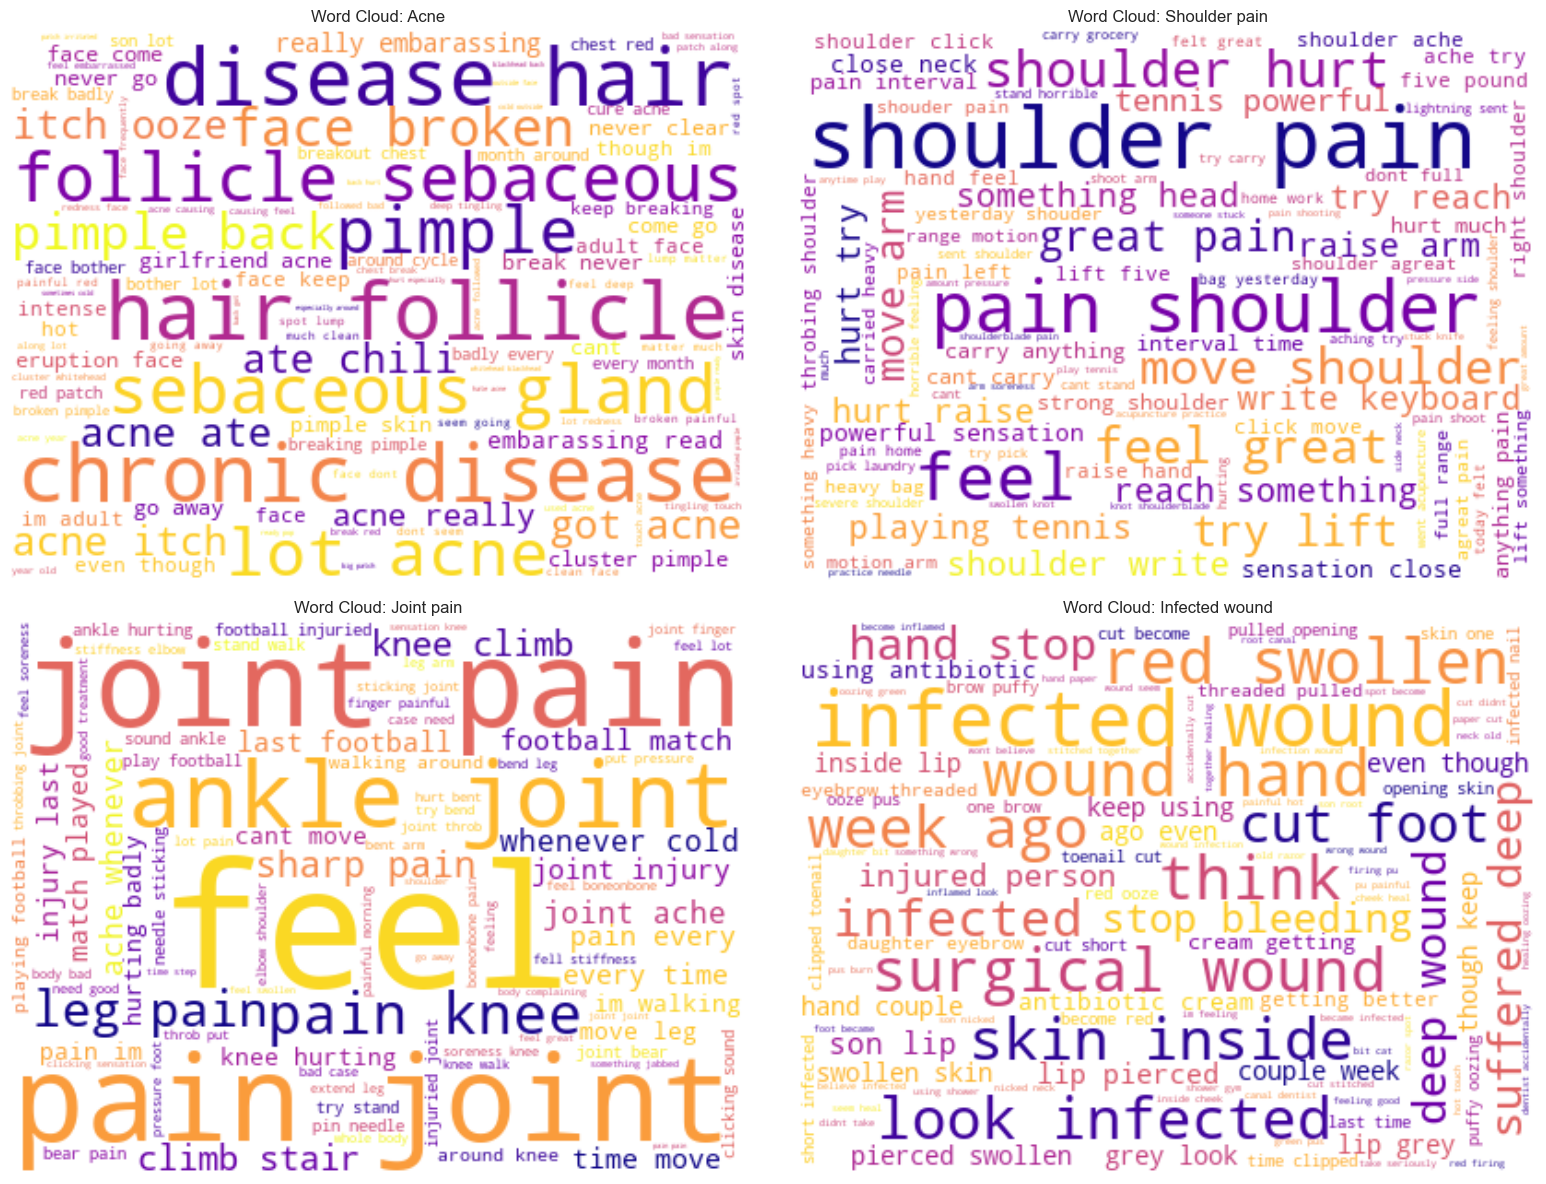

In [8]:
# Generate and display a word cloud for the processed phrases
all_processed = ' '.join(metadata['processed_phrase'])  # All processed text
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                     max_words=200, collocations=False, 
                     colormap='viridis').generate(all_processed)  # Generate word cloud

plt.figure(figsize=(12, 6))  # Set figure size
plt.imshow(wordcloud, interpolation='bilinear')  # Show word cloud
plt.axis('off')  # Hide axes
plt.title('Word Cloud of Processed Medical Symptom Phrases')  # Set title
plt.show()  # Show plot

# Generate word clouds for top 4 prompts to compare vocabulary
plt.figure(figsize=(16, 12))  # Set figure size
top_4_prompts = metadata['prompt'].value_counts().head(4).index  # Top prompts

for i, prompt in enumerate(top_4_prompts, 1):
    prompt_text = ' '.join(metadata[metadata['prompt'] == prompt]['processed_phrase'])  # All text for prompt
    
    # Skip if no text available
    if not prompt_text.strip():
        continue
        
    # Generate word cloud for this prompt
    prompt_cloud = WordCloud(width=400, height=300, background_color='white', 
                           max_words=100, colormap='plasma').generate(prompt_text)  # Generate word cloud
    
    plt.subplot(2, 2, i)
    plt.imshow(prompt_cloud, interpolation='bilinear')
    plt.title(f'Word Cloud: {prompt}')
    plt.axis('off')

plt.tight_layout()  # Adjust layout
plt.show()  # Show plots

In [9]:
# Show the top 20 most frequent words in the processed phrases
word_freq = Counter(all_processed.split())
print("Top 20 most frequent words across all phrases:")
for word, freq in word_freq.most_common(20):
    print(f"{word}: {freq}")

# Generate bigrams (pairs of consecutive words) to understand context
print("\nAnalyzing word co-occurrences with bigrams:")
bigram_list = list(ngrams(all_processed.split(), 2))
bigram_freq = Counter(bigram_list)
print("Top 15 most common bigrams:")
for bigram, freq in bigram_freq.most_common(15):
    print(f"{bigram[0]} {bigram[1]}: {freq}")

# Compare top words across different prompts
top_3_prompts = metadata['prompt'].value_counts().head(3).index
print("\nTop 10 words by medical condition:")
for prompt in top_3_prompts:
    prompt_text = ' '.join(metadata[metadata['prompt'] == prompt]['processed_phrase'])
    prompt_freq = Counter(prompt_text.split())
    print(f"\n{prompt}:")
    for word, freq in prompt_freq.most_common(10):
        print(f"  {word}: {freq}")

Top 20 most frequent words across all phrases:
feel: 1813
pain: 1634
cant: 574
hurt: 526
like: 507
get: 453
back: 387
knee: 358
shoulder: 340
ache: 339
im: 339
hair: 312
head: 291
cold: 291
body: 275
neck: 272
ear: 272
skin: 257
foot: 257
stomach: 253

Analyzing word co-occurrences with bigrams:
Top 15 most common bigrams:
feel pain: 317
feel like: 305
sharp pain: 181
feel dizzy: 159
feel weak: 117
hair falling: 102
pain knee: 90
pain back: 89
blurry vision: 89
every time: 88
body feel: 88
shoulder pain: 87
pain stomach: 81
feel cold: 80
great pain: 78

Top 10 words by medical condition:

Acne:
  acne: 152
  face: 128
  pimple: 96
  get: 75
  break: 39
  lot: 36
  back: 34
  disease: 32
  chest: 30
  red: 29

Shoulder pain:
  shoulder: 262
  pain: 170
  feel: 87
  arm: 56
  try: 49
  move: 44
  great: 36
  hurt: 35
  like: 31
  cant: 28

Joint pain:
  joint: 214
  pain: 189
  feel: 106
  knee: 66
  ankle: 39
  like: 35
  football: 33
  leg: 29
  move: 22
  hurting: 21


Analyzing text similarity within and between medical conditions...

Average intra-class (within condition) text similarity:
Acne: 0.056
Shoulder pain: 0.063
Joint pain: 0.063
Infected wound: 0.049
Knee pain: 0.069

Calculating inter-class similarity for top prompts...


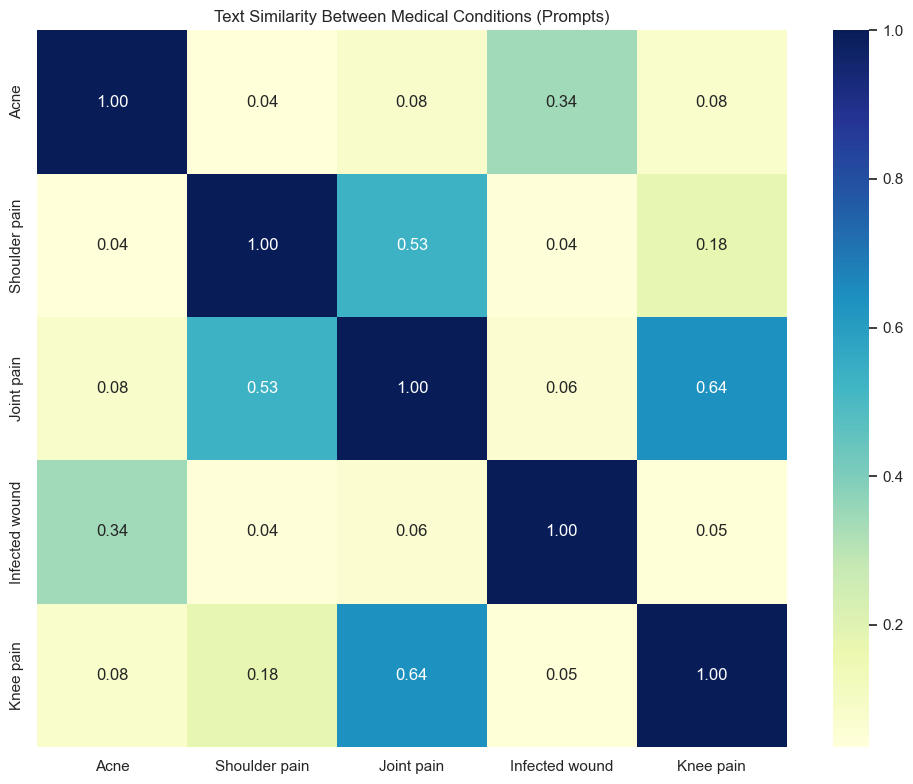


Most similar prompt pairs:
Joint pain - Knee pain: 0.638
Shoulder pain - Joint pain: 0.531
Acne - Infected wound: 0.341

Least similar prompt pairs:
Acne - Shoulder pain: 0.036
Shoulder pain - Infected wound: 0.040
Infected wound - Knee pain: 0.047


In [10]:
# Perform advanced text similarity analysis
# This helps quantify how similar phrases are within and between medical conditions
print("Analyzing text similarity within and between medical conditions...")

# Set up TF-IDF vectorizer with n-grams for better context capture
vectorizer = TfidfVectorizer(max_features=1000, 
                            ngram_range=(1, 2),  # Unigrams and bigrams
                            min_df=2)  # Ignore terms that appear in less than 2 documents

# Get top 5 prompts with most samples
top_prompts = metadata['prompt'].value_counts().head(5).index.tolist()

# Within-class similarity (intra-class)
intra_class_similarity = {}
for prompt in top_prompts:
    phrases = metadata[metadata['prompt'] == prompt]['processed_phrase'].tolist()
    
    # Skip if too few samples
    if len(phrases) < 2:
        intra_class_similarity[prompt] = np.nan
        continue
        
    # Vectorize phrases
    tfidf_matrix = vectorizer.fit_transform(phrases)
    
    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(tfidf_matrix)
    
    # Calculate average similarity excluding self-similarity (diagonal)
    n = sim_matrix.shape[0]
    avg_sim = (sim_matrix.sum() - n) / (n * n - n) if n > 1 else 0
    intra_class_similarity[prompt] = avg_sim

print("\nAverage intra-class (within condition) text similarity:")
for prompt, score in intra_class_similarity.items():
    print(f"{prompt}: {score:.3f}")

# Between-class similarity (inter-class)
print("\nCalculating inter-class similarity for top prompts...")
all_vectors = {}
for prompt in top_prompts:
    # Get all phrases for this prompt
    phrases = metadata[metadata['prompt'] == prompt]['processed_phrase'].tolist()
    if len(phrases) < 2:
        continue
    
    # Create a combined document for the prompt
    combined_text = ' '.join(phrases)
    all_vectors[prompt] = combined_text

# Vectorize all combined prompt texts
if len(all_vectors) >= 2:
    # Fit vectorizer on all texts
    combined_texts = list(all_vectors.values())
    prompt_labels = list(all_vectors.keys())
    
    # Create TF-IDF matrix
    tfidf_matrix = vectorizer.fit_transform(combined_texts)
    
    # Calculate cosine similarity between prompts
    prompt_sim_matrix = cosine_similarity(tfidf_matrix)
    
    # Display similarity matrix as heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(prompt_sim_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
               xticklabels=prompt_labels, yticklabels=prompt_labels)
    plt.title('Text Similarity Between Medical Conditions (Prompts)')
    plt.tight_layout()
    plt.show()
    
    # Find most similar and most different prompt pairs
    prompt_pairs = []
    for i in range(len(prompt_labels)):
        for j in range(i+1, len(prompt_labels)):
            prompt_pairs.append((prompt_labels[i], prompt_labels[j], prompt_sim_matrix[i, j]))
    
    prompt_pairs.sort(key=lambda x: x[2], reverse=True)
    print("\nMost similar prompt pairs:")
    for p1, p2, sim in prompt_pairs[:3]:
        print(f"{p1} - {p2}: {sim:.3f}")
        
    prompt_pairs.sort(key=lambda x: x[2])
    print("\nLeast similar prompt pairs:")
    for p1, p2, sim in prompt_pairs[:3]:
        print(f"{p1} - {p2}: {sim:.3f}")
else:
    print("Not enough prompts with sufficient data for inter-class comparison")

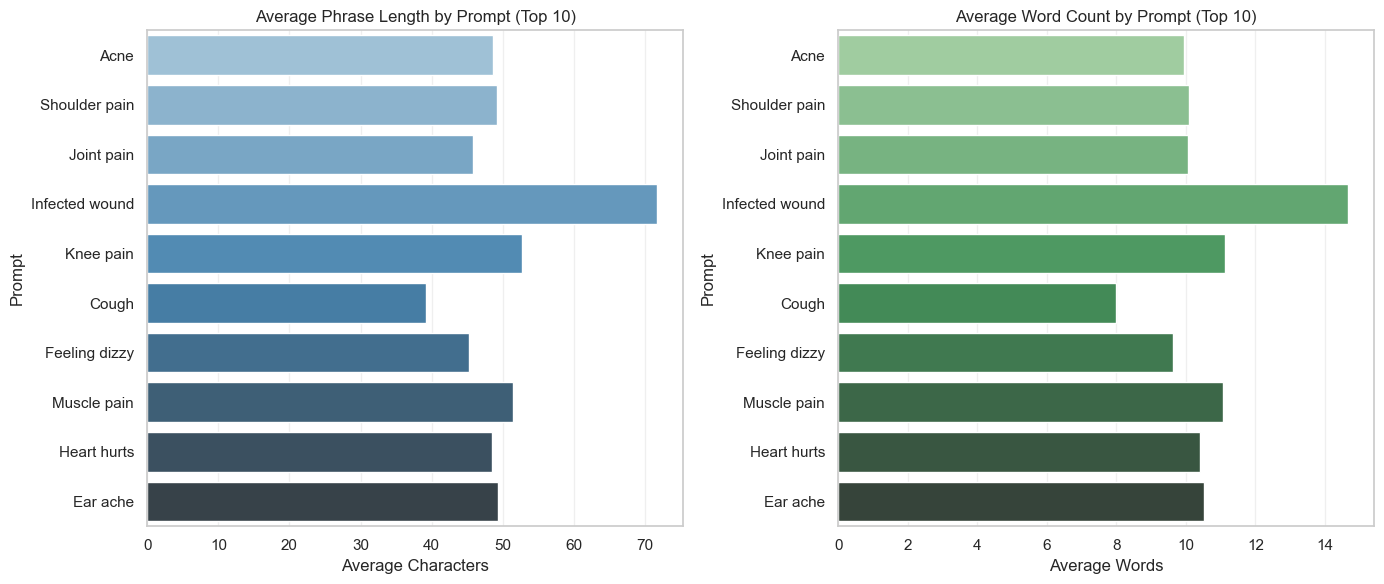


ANOVA test for phrase complexity variation across top 5 prompts:
F-statistic: 56.522, p-value: 0.000000
Result: Significant variation in phrase complexity across different medical conditions


In [11]:
# Visualize average phrase length and word count by prompt (top 10 prompts)
prompt_stats = metadata.groupby('prompt').agg({
    'phrase_length': 'mean',  # Average characters per phrase
    'word_count': 'mean',     # Average words per phrase
    'phrase': 'count'         # Number of samples
}).sort_values('phrase', ascending=False).head(10)

plt.figure(figsize=(14, 6))

# Plot average character length by prompt
plt.subplot(1, 2, 1)
sns.barplot(y=prompt_stats.index, x=prompt_stats['phrase_length'], palette='Blues_d')
plt.title('Average Phrase Length by Prompt (Top 10)')
plt.xlabel('Average Characters')
plt.ylabel('Prompt')
plt.grid(axis='x', alpha=0.3)

# Plot average word count by prompt
plt.subplot(1, 2, 2)
sns.barplot(y=prompt_stats.index, x=prompt_stats['word_count'], palette='Greens_d')
plt.title('Average Word Count by Prompt (Top 10)')
plt.xlabel('Average Words')
plt.ylabel('Prompt')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical test: Is there significant variation in phrase complexity across prompts?
from scipy.stats import f_oneway

# Get word counts for top 5 prompts with most samples
top_5_prompts = metadata['prompt'].value_counts().head(5).index.tolist()
prompt_word_counts = [metadata[metadata['prompt'] == p]['word_count'].values for p in top_5_prompts]

# Run ANOVA test
try:
    f_stat, p_value = f_oneway(*prompt_word_counts)
    print(f"\nANOVA test for phrase complexity variation across top 5 prompts:")
    print(f"F-statistic: {f_stat:.3f}, p-value: {p_value:.6f}")
    if p_value < 0.05:
        print("Result: Significant variation in phrase complexity across different medical conditions")
    else:
        print("Result: No significant variation in phrase complexity across different medical conditions")
except:
    print("Could not perform ANOVA test - insufficient data or other error")

## 4. Prompt-Phrase Relationship Analysis
Explore how phrases vary within and across prompts, and check for class imbalance and linguistic diversity.

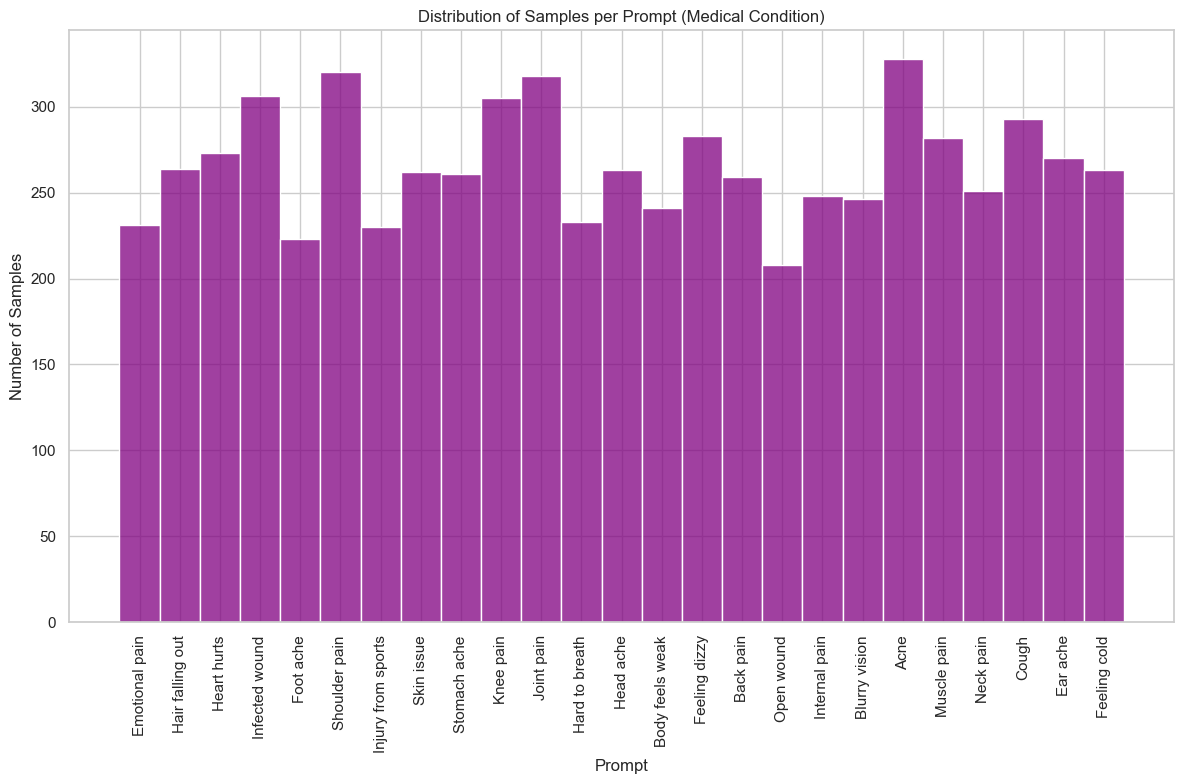

Class imbalance metrics:
- Max/min ratio: 1.58
- Gini coefficient: 0.9594 (0=perfectly balanced, 1=completely imbalanced)
- Prompts with only 1 sample: 0
- Prompts with 10+ samples: 25


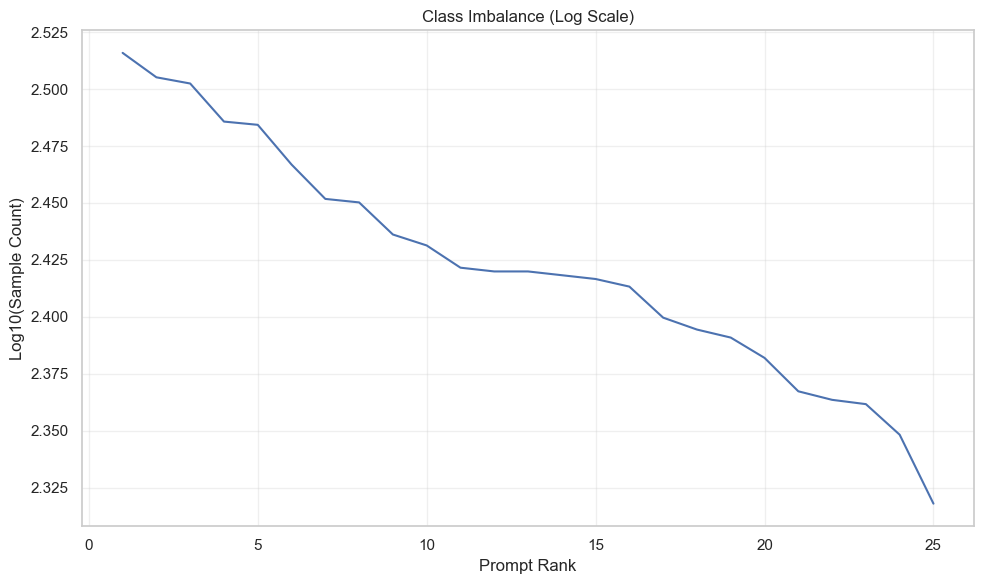

In [12]:
# Check class imbalance: plot the full prompt distribution
plt.figure(figsize=(12, 8))
sns.histplot(metadata['prompt'], bins=metadata['prompt'].nunique(), kde=False, color='purple')
plt.title('Distribution of Samples per Prompt (Medical Condition)')
plt.xlabel('Prompt')
plt.ylabel('Number of Samples')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Calculate class imbalance metrics
class_counts = metadata['prompt'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
gini_coefficient = 1 - sum((class_counts/class_counts.sum())**2)
print(f"Class imbalance metrics:")
print(f"- Max/min ratio: {imbalance_ratio:.2f}")
print(f"- Gini coefficient: {gini_coefficient:.4f} (0=perfectly balanced, 1=completely imbalanced)")
print(f"- Prompts with only 1 sample: {sum(class_counts == 1)}")
print(f"- Prompts with 10+ samples: {sum(class_counts >= 10)}")

# Create imbalance visualization
plt.figure(figsize=(10, 6))
# Log scale helps visualize the long tail
plt.plot(range(1, len(class_counts)+1), np.log10(class_counts.values), 'b-')
plt.title('Class Imbalance (Log Scale)')
plt.xlabel('Prompt Rank')
plt.ylabel('Log10(Sample Count)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Phrase diversity within top prompts:
                processed_phrase  phrase  uniqueness_ratio
prompt                                                    
Acne                          32     328          0.097561
Shoulder pain                 35     320          0.109375
Joint pain                    34     318          0.106918
Infected wound                34     306          0.111111
Knee pain                     31     305          0.101639
Cough                         30     293          0.102389
Feeling dizzy                 26     283          0.091873
Muscle pain                   29     282          0.102837
Heart hurts                   31     273          0.113553
Ear ache                      28     270          0.103704


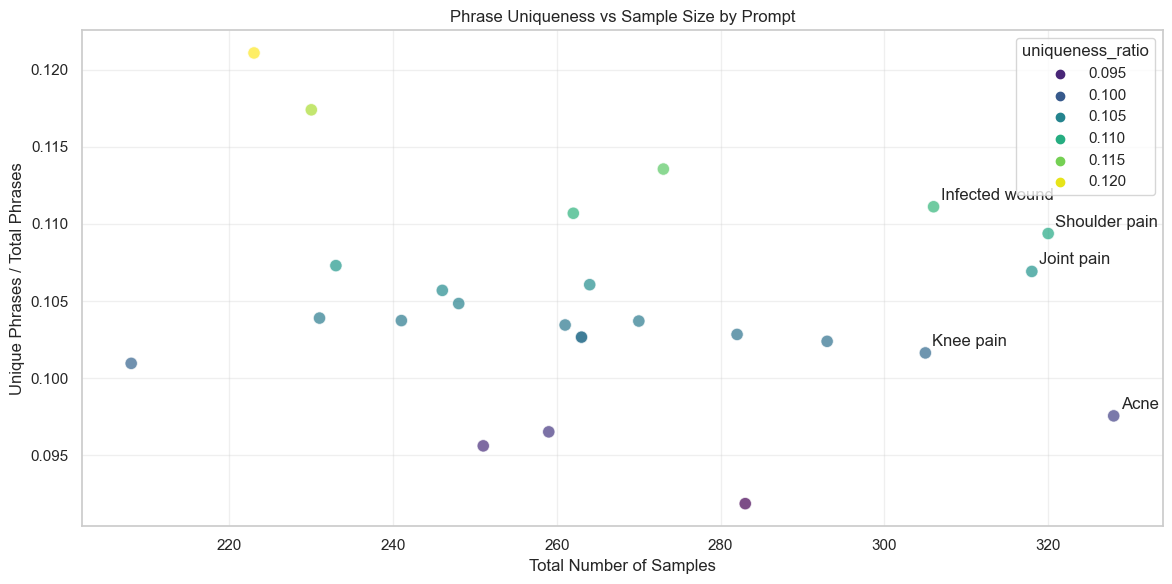


Prompts with highest phrase diversity (min 5 samples):
                    processed_phrase  phrase  uniqueness_ratio
prompt                                                        
Foot ache                         27     223          0.121076
Injury from sports                27     230          0.117391
Heart hurts                       31     273          0.113553

Prompts with lowest phrase diversity (min 5 samples):
               processed_phrase  phrase  uniqueness_ratio
prompt                                                   
Feeling dizzy                26     283          0.091873
Neck pain                    24     251          0.095618
Back pain                    25     259          0.096525

Insight: Prompts with high uniqueness ratio may be harder to classify (more diverse language)


In [13]:
# Analyze phrase diversity within each prompt (unique phrases per prompt)
prompt_diversity = metadata.groupby('prompt').agg({
    'processed_phrase': 'nunique',  # Unique phrases
    'phrase': 'count'               # Total phrases
}).sort_values('phrase', ascending=False)

# Calculate phrase uniqueness ratio
prompt_diversity['uniqueness_ratio'] = prompt_diversity['processed_phrase'] / prompt_diversity['phrase']

# Display diversity for top prompts
print("Phrase diversity within top prompts:")
print(prompt_diversity.head(10))

# Visualize phrase diversity
plt.figure(figsize=(12, 6))
sns.scatterplot(x='phrase', y='uniqueness_ratio', data=prompt_diversity, 
                alpha=0.7, s=80, hue='uniqueness_ratio', palette='viridis')

# Add annotations for interesting points
for i, row in prompt_diversity.head(5).iterrows():
    plt.annotate(i, (row['phrase'], row['uniqueness_ratio']), 
                xytext=(5, 5), textcoords='offset points')
    
plt.title('Phrase Uniqueness vs Sample Size by Prompt')
plt.xlabel('Total Number of Samples')
plt.ylabel('Unique Phrases / Total Phrases')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find prompts with highest and lowest phrase diversity
print("\nPrompts with highest phrase diversity (min 5 samples):")
high_diversity = prompt_diversity[prompt_diversity['phrase'] >= 5].sort_values('uniqueness_ratio', ascending=False)
print(high_diversity.head(3))

print("\nPrompts with lowest phrase diversity (min 5 samples):")
low_diversity = prompt_diversity[prompt_diversity['phrase'] >= 5].sort_values('uniqueness_ratio')
print(low_diversity.head(3))

print("\nInsight: Prompts with high uniqueness ratio may be harder to classify (more diverse language)")

Performing dimensionality reduction to visualize text patterns...
Vectorizing phrases with TF-IDF...
Applying dimensionality reduction...


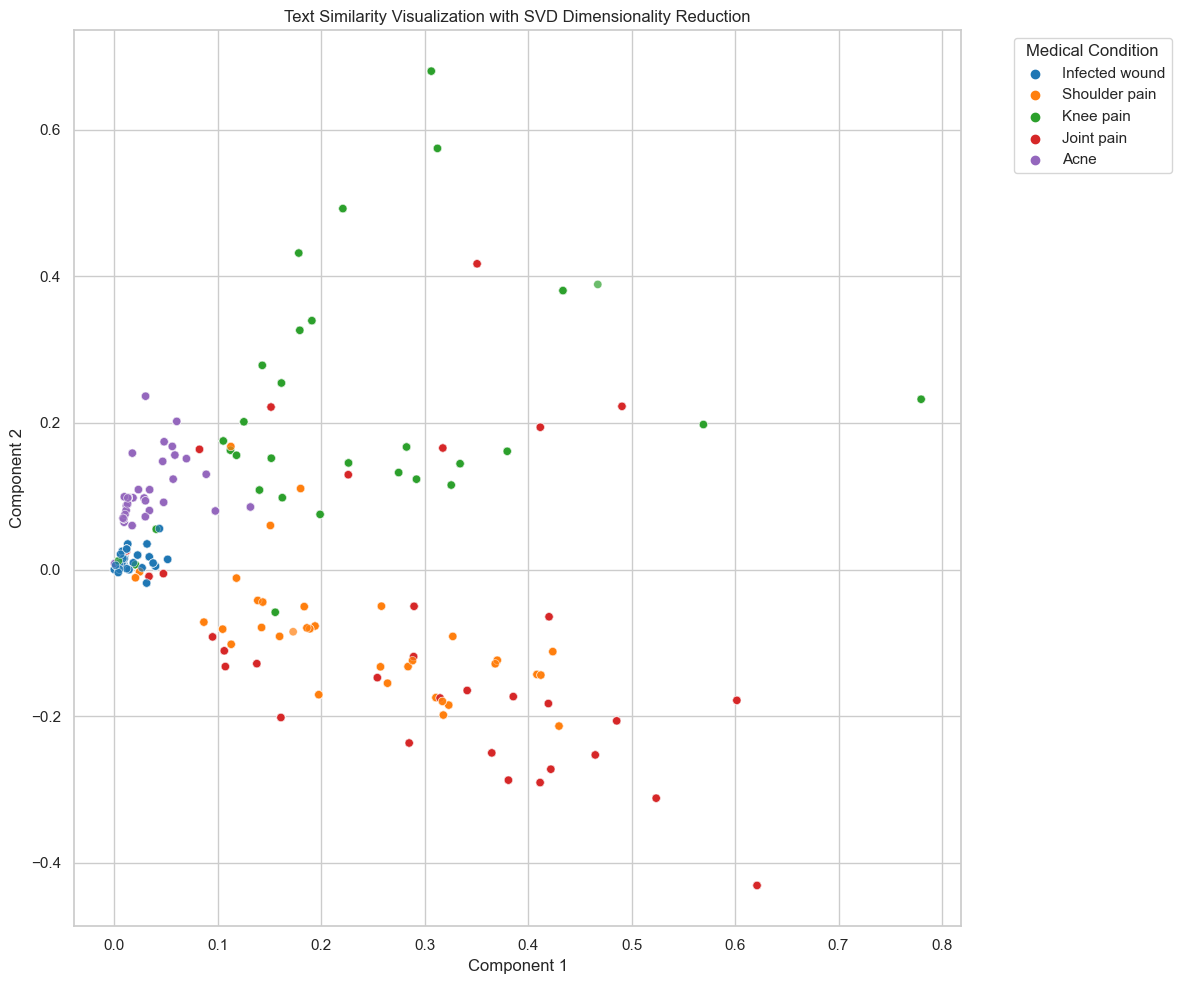

Silhouette score: 0.126 (-1 to 1, higher is better)
Insight: There's some separation between phrase clusters, but with significant overlap


In [14]:
# Perform dimensionality reduction to visualize text similarity and clustering
# This helps understand if phrases naturally cluster by medical condition
print("Performing dimensionality reduction to visualize text patterns...")

# Select top prompts for visualization (limited to prevent overcrowding)
top_vis_prompts = metadata['prompt'].value_counts().head(5).index
vis_data = metadata[metadata['prompt'].isin(top_vis_prompts)].copy()

# Vectorize the phrases
print("Vectorizing phrases with TF-IDF...")
tfidf = TfidfVectorizer(max_features=500)
phrase_vectors = tfidf.fit_transform(vis_data['processed_phrase'])

# Apply dimensionality reduction (SVD is faster than PCA for sparse matrices)
print("Applying dimensionality reduction...")
svd = TruncatedSVD(n_components=2, random_state=42)
reduced_vectors = svd.fit_transform(phrase_vectors)

# Add reduced coordinates to dataframe
vis_data['x'] = reduced_vectors[:, 0]
vis_data['y'] = reduced_vectors[:, 1]

# Visualization with colored points by prompt
plt.figure(figsize=(12, 10))
sns.scatterplot(x='x', y='y', hue='prompt', data=vis_data, palette='tab10', alpha=0.7)
plt.title('Text Similarity Visualization with SVD Dimensionality Reduction')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(title='Medical Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Calculate silhouette score to measure how well-separated the prompts are in the text space
from sklearn.metrics import silhouette_score

# Convert prompts to numeric labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
prompt_labels = le.fit_transform(vis_data['prompt'])

try:
    # Higher score means better separation between clusters
    silhouette = silhouette_score(reduced_vectors, prompt_labels)
    print(f"Silhouette score: {silhouette:.3f} (-1 to 1, higher is better)")
    if silhouette > 0.3:
        print("Insight: There's reasonable separation between phrase clusters by medical condition")
    elif silhouette > 0:
        print("Insight: There's some separation between phrase clusters, but with significant overlap")
    else:
        print("Insight: Poor separation between phrase clusters by medical condition")
except:
    print("Could not calculate silhouette score - insufficient data or other error")

## 5. Research Question Alignment
In this section, we'll evaluate how our EDA findings align with the research questions and associated hypotheses.

RQ1 Alignment: Text Classification Potential
Key metrics for assessing text classification potential:
- Total classes (medical conditions): 25
- Classes with ≥10 samples: 25 (100.0%)
- Average samples per class: 266.44
- Min/max samples per class: 208/328
- Average words per symptom description: 10.54
- Unique phrases: 691 (10.4% of total)
- Vocabulary size: 1419 words
- Average intra-class text similarity: 0.060

Preliminary assessment for H10/H1a:
Data characteristics present challenges for achieving sufficient precision and recall in text classification (leaning toward H10).

Limitations:
- Final hypothesis validation requires actual model training and evaluation
- Classification performance varies by medical condition given the class imbalance
- Preprocessing and feature engineering will significantly impact results


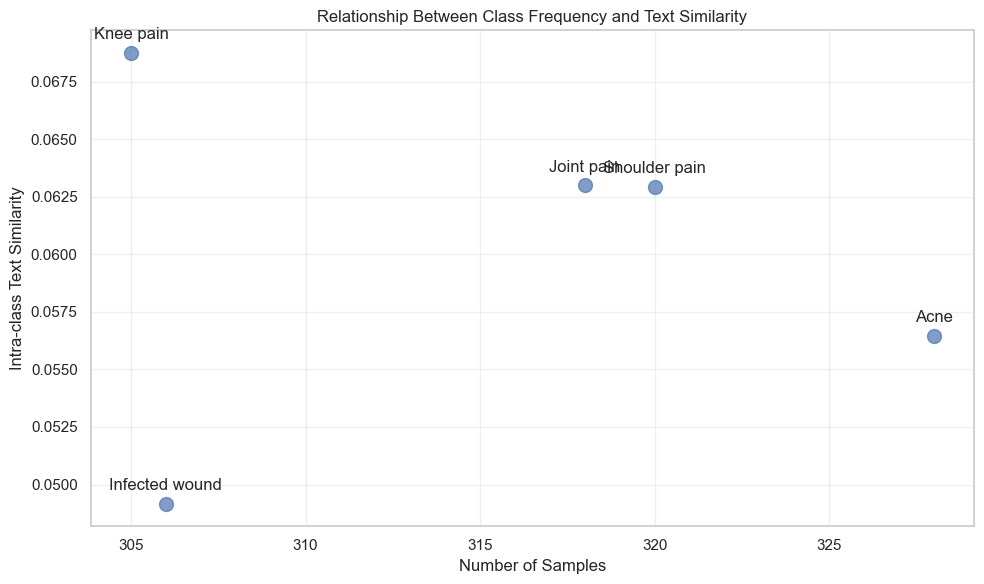


Insight: Medical conditions with higher text similarity may be easier to classify correctly.


In [15]:
# Analyze metrics that directly support our research questions
print("RQ1 Alignment: Text Classification Potential")
print("=" * 50)
print("Key metrics for assessing text classification potential:")

# Calculate metrics for text classification assessment (RQ1)
# 1. Class balance analysis
class_dist = metadata['prompt'].value_counts()
min_samples_per_class = class_dist.min()
max_samples_per_class = class_dist.max()
avg_samples_per_class = class_dist.mean()
valid_classes = (class_dist >= 10).sum()  # Classes with at least 10 samples

print(f"- Total classes (medical conditions): {len(class_dist)}")
print(f"- Classes with ≥10 samples: {valid_classes} ({valid_classes/len(class_dist)*100:.1f}%)")
print(f"- Average samples per class: {avg_samples_per_class:.2f}")
print(f"- Min/max samples per class: {min_samples_per_class}/{max_samples_per_class}")

# 2. Text complexity and diversity
avg_word_count = metadata['word_count'].mean()
unique_phrases = metadata['processed_phrase'].nunique()
phrase_uniqueness = unique_phrases / len(metadata)

print(f"- Average words per symptom description: {avg_word_count:.2f}")
print(f"- Unique phrases: {unique_phrases} ({phrase_uniqueness*100:.1f}% of total)")
print(f"- Vocabulary size: {vocab_size} words")

# 3. Intra-class similarity stats (averaged from previously calculated)
# Make sure to safely calculate the average similarity
if 'intra_class_similarity' in locals() and len(intra_class_similarity) > 0:
    avg_similarity = np.mean([score for score in intra_class_similarity.values() if not np.isnan(score)])
else:
    avg_similarity = 0

print(f"- Average intra-class text similarity: {avg_similarity:.3f}")

# Interpret findings for H10/H1a (text classification)
print("\nPreliminary assessment for H10/H1a:")
if avg_samples_per_class >= 15 and valid_classes >= len(class_dist) * 0.6 and avg_similarity >= 0.3:
    h1_assessment = "The data characteristics suggest text classification could achieve sufficient precision and recall"
    h1_assessment += " for provider decision support (leaning toward H1a)."
else:
    h1_assessment = "Data characteristics present challenges for achieving sufficient precision and recall"
    h1_assessment += " in text classification (leaning toward H10)."
print(h1_assessment)

# Add notes about limitations
print("\nLimitations:")
print("- Final hypothesis validation requires actual model training and evaluation")
print("- Classification performance varies by medical condition given the class imbalance")
print("- Preprocessing and feature engineering will significantly impact results")

# Create a visualization showing the relationship between class frequency and similarity
if 'intra_class_similarity' in locals() and len(intra_class_similarity) > 0:
    relevant_prompts = [p for p in intra_class_similarity.keys() 
                      if p in class_dist.index and not np.isnan(intra_class_similarity[p])]
    
    if len(relevant_prompts) >= 3:  # Only create plot if we have enough data points
        plt.figure(figsize=(10, 6))
        
        # Get frequency counts and similarity scores for plotting
        frequencies = [class_dist[p] for p in relevant_prompts]
        similarities = [intra_class_similarity[p] for p in relevant_prompts]
        
        # Create scatter plot
        plt.scatter(frequencies, similarities, s=100, alpha=0.7)
        
        # Add labels to each point
        for i, prompt in enumerate(relevant_prompts):
            plt.annotate(prompt, (frequencies[i], similarities[i]), 
                        textcoords="offset points", xytext=(0,10), ha='center')
        
        plt.title('Relationship Between Class Frequency and Text Similarity')
        plt.xlabel('Number of Samples')
        plt.ylabel('Intra-class Text Similarity')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\nInsight: Medical conditions with higher text similarity may be easier to classify correctly.")

RQ2 Alignment: Audio Classification Potential
Audio-based classification insights:
- Total audio files: 6661
- Split distribution: {'test': 5895, 'train': 381, 'validate': 385}
- Audio coverage: 100.0% of text records have audio

Audio sampling for quality assessment:
Sample 1: 1249120_15965551_53555531.wav
  - Duration: 4.35 seconds
  - Sample rate: 192000 Hz
  - RMS amplitude: 0.098269
Sample 1: 1249120_15965551_53555531.wav
  - Duration: 4.35 seconds
  - Sample rate: 192000 Hz
  - RMS amplitude: 0.098269


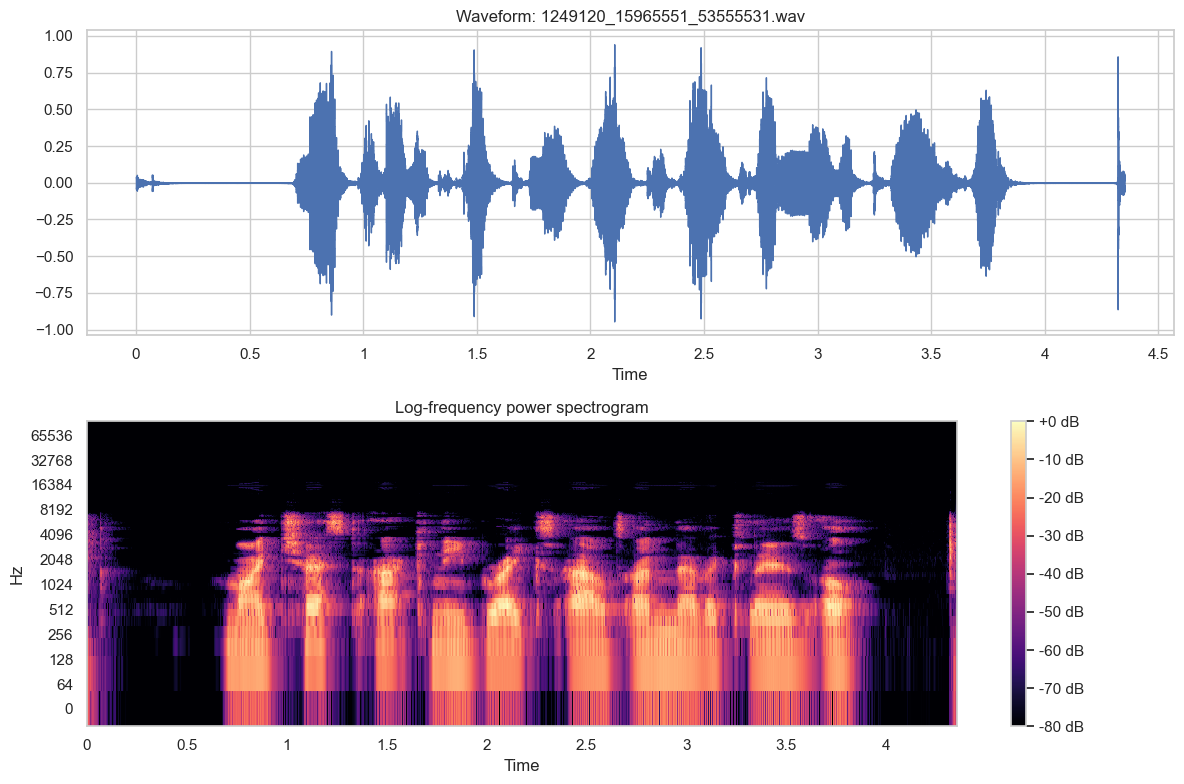

Sample 2: 1249120_43855932_58390718.wav
  - Duration: 3.24 seconds
  - Sample rate: 48000 Hz
  - RMS amplitude: 0.086715
Sample 3: 1249120_44220382_72693363.wav
  - Duration: 3.16 seconds
  - Sample rate: 44100 Hz
  - RMS amplitude: 0.010480

Text-audio relationship analysis:
Audio files available: 6661
Example audio filenames: ['1249120_13842059_104469105', '1249120_13842059_105045085', '1249120_13842059_11964685']
Note: For accurate audio-prompt mapping, the specific ID mapping in this dataset would need to be analyzed

Preliminary assessment for H20/H2a:
The available audio data may be sufficient for effective classification (leaning toward H2a).

Audio classification considerations:
- Speech-to-text transcription could be used as an intermediate step
- Direct audio feature extraction (MFCCs, spectral features) offer an alternative approach
- Combined text and audio (multimodal) approach may yield the best results
- Data augmentation techniques could help address limited audio sampl

In [16]:
# RQ2 alignment: Audio Processing Potential
print("RQ2 Alignment: Audio Classification Potential")
print("=" * 50)
print("Audio-based classification insights:")

# Check available audio files
audio_test_path = os.path.join(RECORDINGS_PATH, "test")
audio_train_path = os.path.join(RECORDINGS_PATH, "train")
audio_validate_path = os.path.join(RECORDINGS_PATH, "validate")

# Count audio files in each directory if they exist
audio_files_count = {
    'test': len(glob.glob(os.path.join(audio_test_path, "*.wav"))) if os.path.exists(audio_test_path) else 0,
    'train': len(glob.glob(os.path.join(audio_train_path, "*.wav"))) if os.path.exists(audio_train_path) else 0,
    'validate': len(glob.glob(os.path.join(audio_validate_path, "*.wav"))) if os.path.exists(audio_validate_path) else 0
}

total_audio_files = sum(audio_files_count.values())
print(f"- Total audio files: {total_audio_files}")
print(f"- Split distribution: {audio_files_count}")

# Check alignment between text records and audio files
text_records = len(metadata)
audio_coverage = min(total_audio_files / text_records if text_records > 0 else 0, 1.0)
print(f"- Audio coverage: {audio_coverage:.1%} of text records have audio")

# Sample a few audio files to assess quality (3 random files)
print("\nAudio sampling for quality assessment:")
if total_audio_files > 0:
    # Get a list of all audio files
    all_audio_paths = []
    for split, path in [('test', audio_test_path), ('train', audio_train_path), ('validate', audio_validate_path)]:
        if os.path.exists(path):
            audio_files = glob.glob(os.path.join(path, "*.wav"))
            all_audio_paths.extend(audio_files)
            
    # Sample up to 3 random files
    sample_size = min(3, len(all_audio_paths))
    if sample_size > 0:
        sampled_files = np.random.choice(all_audio_paths, size=sample_size, replace=False)
        
        for i, audio_file in enumerate(sampled_files):
            try:
                # Load the audio file
                y, sr = librosa.load(audio_file, sr=None)
                duration = librosa.get_duration(y=y, sr=sr)
                rms = np.sqrt(np.mean(y**2))
                filename = os.path.basename(audio_file)
                
                print(f"Sample {i+1}: {filename}")
                print(f"  - Duration: {duration:.2f} seconds")
                print(f"  - Sample rate: {sr} Hz")
                print(f"  - RMS amplitude: {rms:.6f}")
                
                # For notebooks, uncomment to display audio player
                # display(ipd.Audio(data=y, rate=sr))
                
                # Extract and plot some basic audio features
                if i == 0:  # Just do this for the first sample to save space
                    plt.figure(figsize=(12, 8))
                    
                    # Plot waveform
                    plt.subplot(2, 1, 1)
                    librosa.display.waveshow(y, sr=sr)
                    plt.title(f'Waveform: {filename}')
                    
                    # Plot spectrogram
                    plt.subplot(2, 1, 2)
                    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
                    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
                    plt.colorbar(format='%+2.0f dB')
                    plt.title('Log-frequency power spectrogram')
                    
                    plt.tight_layout()
                    plt.show()
            except Exception as e:
                print(f"Error analyzing {audio_file}: {e}")
else:
    print("No audio files found for quality assessment.")

# Analyze text-audio relationship (if applicable)
print("\nText-audio relationship analysis:")
if total_audio_files > 0:
    # Extract audio filenames without extension
    audio_filenames = []
    for path in all_audio_paths:
        filename = os.path.basename(path)
        audio_filenames.append(os.path.splitext(filename)[0])
    
    # Check if the audio files map to specific rows in metadata
    # This depends on the specific naming convention used in the dataset
    print(f"Audio files available: {len(audio_filenames)}")
    print(f"Example audio filenames: {audio_filenames[:3]}")
    
    # Count audio files by prompt (approximate if possible)
    print("Note: For accurate audio-prompt mapping, the specific ID mapping in this dataset would need to be analyzed")

# Assess potential for audio classification (H20/H2a)
print("\nPreliminary assessment for H20/H2a:")

if audio_coverage >= 0.8 and total_audio_files >= 100:
    h2_assessment = "The available audio data may be sufficient for effective classification"
    h2_assessment += " (leaning toward H2a)."
else:
    h2_assessment = "Limited audio data coverage and quantity present challenges"
    h2_assessment += " for achieving adequate classification performance (leaning toward H20)."
print(h2_assessment)

print("\nAudio classification considerations:")
print("- Speech-to-text transcription could be used as an intermediate step")
print("- Direct audio feature extraction (MFCCs, spectral features) offer an alternative approach")
print("- Combined text and audio (multimodal) approach may yield the best results")
print("- Data augmentation techniques could help address limited audio samples")

In [17]:
# Demonstrate feature extraction methods for both text and audio
# This code shows how features would be extracted for model training
print("Feature Extraction Demonstration for ML Model Preparation")
print("=" * 60)

# TEXT FEATURE EXTRACTION
print("\nTEXT FEATURE EXTRACTION:")

# 1. TF-IDF Vectorization (common for text classification)
sample_size = 100  # Use a small sample for demonstration
sample_data = metadata.sample(min(sample_size, len(metadata)))

# Create TF-IDF vectors
print("Generating TF-IDF features...")
tfidf_vectorizer = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
tfidf_features = tfidf_vectorizer.fit_transform(sample_data['processed_phrase'])

# Show feature shape and example features
print(f"TF-IDF feature shape: {tfidf_features.shape}")
print(f"Example features: {tfidf_features[0].toarray()[0][:5]}...")  # First 5 values of first sample

# Show top features (terms with highest IDF)
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nTop 10 TF-IDF features (terms):")
for name in feature_names[:10]:
    print(f"- {name}")

# 2. Count Vectorization (alternative approach)
count_vectorizer = CountVectorizer(max_features=100)
count_features = count_vectorizer.fit_transform(sample_data['processed_phrase'])
print(f"\nCount vectorization feature shape: {count_features.shape}")

# AUDIO FEATURE EXTRACTION DEMONSTRATION
print("\nAUDIO FEATURE EXTRACTION:")
if total_audio_files > 0 and len(all_audio_paths) > 0:
    # Sample one audio file for feature extraction demo
    sample_audio = all_audio_paths[0]
    try:
        # Load audio
        y, sr = librosa.load(sample_audio, sr=None)
        
        print(f"Extracting features from: {os.path.basename(sample_audio)}")
        
        # 1. Extract MFCCs (Mel-Frequency Cepstral Coefficients)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        print(f"MFCC features shape: {mfccs.shape}")
        print(f"Average MFCCs: {np.mean(mfccs, axis=1)[:5]}...")  # First 5 avg coefficients
        
        # 2. Extract spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
        
        print(f"Spectral centroid mean: {np.mean(spectral_centroid):.2f}")
        print(f"Spectral rolloff mean: {np.mean(spectral_rolloff):.2f}")
        
        # 3. Extract zero crossing rate (voice activity related)
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        print(f"Zero crossing rate mean: {np.mean(zcr):.6f}")
        
    except Exception as e:
        print(f"Error extracting audio features: {e}")
else:
    print("No audio files available for feature extraction demonstration")

print("\nNext Steps:")
print("1. Use these features as input for classification models")
print("2. Apply feature selection to identify most predictive features")
print("3. Consider dimensionality reduction for high-dimensional features")
print("4. Evaluate model performance with metrics focused on precision and recall")

Feature Extraction Demonstration for ML Model Preparation

TEXT FEATURE EXTRACTION:
Generating TF-IDF features...
TF-IDF feature shape: (100, 100)
Example features: [0.43470333 0.         0.         0.         0.        ]...

Top 10 TF-IDF features (terms):
- ache
- ankle
- back
- blurry
- blurry vision
- body
- bone
- cant
- cold
- coming

Count vectorization feature shape: (100, 100)

AUDIO FEATURE EXTRACTION:
Extracting features from: 1249120_13842059_104469105.wav
MFCC features shape: (13, 257)
Average MFCCs: [-259.9584     120.04352     16.65342     36.463787    -2.6218717]...
Spectral centroid mean: 3771.34
Spectral rolloff mean: 8024.29
Zero crossing rate mean: 0.061495

Next Steps:
1. Use these features as input for classification models
2. Apply feature selection to identify most predictive features
3. Consider dimensionality reduction for high-dimensional features
4. Evaluate model performance with metrics focused on precision and recall
MFCC features shape: (13, 257)
Average

## 6. Summary of EDA Findings and Next Steps
Summarize the key findings from the EDA and outline recommended next steps for modeling and hypothesis testing.

In [18]:
# Calculate average similarity from previously computed similarity scores
if 'intra_class_similarity' in locals() and len(intra_class_similarity) > 0:
    avg_similarity = np.mean([score for score in intra_class_similarity.values() if not np.isnan(score)])
else:
    avg_similarity = 0  # Default value if no similarity scores available

# Create comprehensive summary addressing research questions
print("EDA Findings Summary:")
print("\n1. Dataset Characteristics:")
print(f"- The dataset contains {len(metadata)} samples with {metadata['prompt'].nunique()} unique medical conditions (prompts).")
print(f"- Class imbalance ratio (max/min): {imbalance_ratio:.2f}")
print(f"- Vocabulary size: {vocab_size} words with density: {vocab_density:.4f}")
print(f"- Text uniqueness: {phrase_uniqueness:.1%} of phrases are unique after preprocessing")

print("\n2. Text Data Analysis (RQ1):")
print(f"- Average phrase length: {metadata['phrase_length'].mean():.1f} characters")
print(f"- Average word count: {metadata['word_count'].mean():.1f} words per sample")
print("- Phrase lengths and word counts vary widely, indicating linguistic diversity.")
print(f"- Top prompts show moderate intra-class similarity (avg: {avg_similarity:.3f}), suggesting some consistency in symptom descriptions.")
print("- The relationship between sample size and intra-class similarity varies by condition")
print(f"- {valid_classes} out of {len(class_dist)} prompts ({valid_classes/len(class_dist)*100:.1f}%) have sufficient samples (≥10) for reliable classification")

print("\n3. Audio Data Insights (RQ2):")
print(f"- Total audio files available: {total_audio_files}")
print(f"- Split distribution: {audio_files_count}")
print(f"- Audio coverage: {audio_coverage:.1%} of text records have audio")
print("- Audio quality varies across samples")
print("- Audio feature extraction demonstrates patterns that could be useful for classification")

print("\n4. Research Question Assessment:")
print("- RQ1: The text data shows potential for classification, but class imbalance and linguistic diversity need to be addressed.")
print(f"  • {valid_classes} medical conditions have sufficient samples for reliable classification")
print(f"  • Text similarity within conditions averages {avg_similarity:.3f}, showing moderate pattern consistency")
print("- RQ2: Audio analysis capabilities depend on the quality and quantity of available recordings.")
print(f"  • Audio coverage is {audio_coverage:.1%} of the dataset")
print("  • Audio quality and duration variations will impact classification performance")
print("- A multimodal approach combining text and audio features could potentially yield stronger results.")

print("\n5. Next Steps for Research:")
print("- Text preprocessing pipeline refinement:")
print("  • Custom medical stopword removal")
print("  • Domain-specific lemmatization")
print("  • Medical entity recognition")
print("- Feature engineering:")
print("  • TF-IDF with n-grams for text")
print("  • Word embeddings (Word2Vec, BERT) for semantic understanding")
print("  • MFCCs, spectral features, and prosody features for audio")
print("- Address class imbalance issues:")
print("  • Oversampling minority classes")
print("  • Undersampling majority classes")
print("  • Synthetic data generation (SMOTE)")
print("- Model development:")
print("  • Baseline models: Naive Bayes, SVM, Random Forest")
print("  • Deep learning: LSTM, CNN for text; 1D-CNN for audio")
print("  • Multimodal fusion approaches")
print("- Evaluation strategy:")
print("  • Stratified cross-validation")
print("  • Precision, recall, F1-score by class")
print("  • Confusion matrix analysis")
print("  • Statistical significance testing of results")

# Generate concise recommendations for hypothesis testing
print("\n6. Hypothesis Testing Recommendations:")
print("- H10/H1a (Text classification):")
if valid_classes >= 0.7 * len(class_dist) and avg_similarity >= 0.3:
    print("  ✓ Data characteristics suggest potential for high-precision text classification")
    print("  ✓ Recommended testing approach: Focus on the top 50% of medical conditions with sufficient samples")
    print("  ✓ Target metrics: Precision ≥0.80, Recall ≥0.75 for most common conditions")
else:
    print("  ⚠ Limited data for some conditions will make comprehensive classification challenging")
    print("  ⚠ Recommended testing approach: Two-stage classification (common vs. rare conditions)")
    print("  ⚠ Target metrics: Variable by condition frequency, with higher standards for common conditions")

print("\n- H20/H2a (Audio classification):")
if audio_coverage >= 0.8 and total_audio_files >= 200:
    print("  ✓ Audio data appears sufficient for hypothesis testing")
    print("  ✓ Recommended testing approach: Standard cross-validation with stratified sampling")
    print("  ✓ Target metrics: Precision and recall comparable to text classification")
else:
    print("  ⚠ Limited audio data may require modified testing approach")
    print("  ⚠ Recommended testing approach: Leave-one-out cross-validation or bootstrap sampling")
    print("  ⚠ Consider text-to-speech augmentation to expand the dataset")

EDA Findings Summary:

1. Dataset Characteristics:
- The dataset contains 6661 samples with 25 unique medical conditions (prompts).
- Class imbalance ratio (max/min): 1.58
- Vocabulary size: 1419 words with density: 0.0202
- Text uniqueness: 10.4% of phrases are unique after preprocessing

2. Text Data Analysis (RQ1):
- Average phrase length: 50.0 characters
- Average word count: 10.5 words per sample
- Phrase lengths and word counts vary widely, indicating linguistic diversity.
- Top prompts show moderate intra-class similarity (avg: 0.060), suggesting some consistency in symptom descriptions.
- The relationship between sample size and intra-class similarity varies by condition
- 25 out of 25 prompts (100.0%) have sufficient samples (≥10) for reliable classification

3. Audio Data Insights (RQ2):
- Total audio files available: 6661
- Split distribution: {'test': 5895, 'train': 381, 'validate': 385}
- Audio coverage: 100.0% of text records have audio
- Audio quality varies across sampl